In [144]:

# IMPORTS

# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers




In [145]:
df = pd.read_csv('lego_sets.csv')

df.dtypes

ages                     str
list_price           float64
num_reviews          float64
piece_count          float64
play_star_rating     float64
prod_desc                str
prod_id              float64
prod_long_desc           str
review_difficulty        str
set_name                 str
star_rating          float64
theme_name               str
val_star_rating      float64
country                  str
dtype: object

In [146]:
df['ages'].value_counts()
# Separate this column to two new columns - minAge and maxAge

ages
6-12     1476
7-14     1421
8-14     1180
4-7       957
5-12      911
10+       870
2-5       840
7-12      723
9-14      624
16+       420
8-12      350
4-99      311
12+       298
6-14      233
8+        226
1½-3      213
14+       212
10-21     184
6+        148
10-16     148
1½-5      113
9-16       92
5+         71
11-16      66
9-12       46
12-16      42
4+         21
9+         21
5-8        21
10-14      21
7+          2
Name: count, dtype: int64

In [147]:
# This code is 98% claude
# The primary function is to separate the 'ages' column into two different columns - min and max ages

import re

def parse_age(age_str):
    if pd.isna(age_str):
        return pd.Series([None, None])
    
    age_str = str(age_str).strip()
    age_str = age_str.replace('½', '.5')  # handle fractions like 1½ -> 1.5
    
    # Case: "99+" or "12+"
    if '+' in age_str:
        match = re.search(r'[\d.]+', age_str)
        num = float(match.group()) if match else None
        return pd.Series([num, None])
    
    # Case: "12-16" (range)
    if '-' in age_str:
        parts = age_str.split('-')
        try:
            return pd.Series([float(parts[0].strip()), float(parts[1].strip())])
        except (ValueError, IndexError):
            return pd.Series([None, None])
    
    # Case: single number like "2"
    match = re.fullmatch(r'[\d.]+', age_str)
    if match:
        num = float(age_str)
        return pd.Series([num, num])
    
    return pd.Series([None, None])

df[['min_age', 'max_age']] = df['ages'].apply(parse_age)

df['max_age'] = df['max_age'].fillna(99) # To fill the na, assuming the lego sets without max age have the max age of 99



In [148]:
df['country'].unique()

<StringArray>
['US', 'AU', 'AT', 'BE', 'CA', 'CH', 'CZ', 'DE', 'DN', 'ES', 'FI', 'FR', 'GB',
 'IE', 'IT', 'LU', 'NO', 'NL', 'NZ', 'PL', 'PT']
Length: 21, dtype: str

In [149]:
country_to_continent = {
    'US': 'North America',
    'CA': 'North America',
    'AU': 'Oceania',
    'NZ': 'Oceania',
    'AT': 'Europe',
    'BE': 'Europe',
    'CH': 'Europe',
    'CZ': 'Europe',
    'DE': 'Europe',
    'DN': 'Europe',   
    'ES': 'Europe',
    'FI': 'Europe',
    'FR': 'Europe',
    'GB': 'Europe',
    'IE': 'Europe',
    'IT': 'Europe',
    'LU': 'Europe',
    'NO': 'Europe',
    'NL': 'Europe',
    'PL': 'Europe',
    'PT': 'Europe',
}

df['continent'] = df['country'].map(country_to_continent)
df = df.drop('country', axis=1)

In [151]:
df.columns

Index(['ages', 'list_price', 'num_reviews', 'piece_count', 'play_star_rating',
       'prod_desc', 'prod_id', 'prod_long_desc', 'review_difficulty',
       'set_name', 'star_rating', 'theme_name', 'val_star_rating', 'min_age',
       'max_age', 'continent'],
      dtype='str')

In [152]:
# dropping unnessary columns
droppables = ['ages', 'prod_desc', 'prod_long_desc', 'theme_name', 'set_name', 'prod_id' ]
df = df.drop(droppables, axis=1)

In [153]:
df = df.dropna() # Drops 1/10th of the data so not too bad

In [154]:
# df.isna().sum() # Lots of NAs, trying KNNimputer for now

# from sklearn.impute import KNNImputer

# imputer = KNNImputer(n_neighbors=5)

# df = pd.DataFrame(
#     imputer.fit_transform(df),
#     columns=df.columns,
#     index=df.index
# )

# int_cols = ['review_difficulty'] 
# df[int_cols] = df[int_cols].round().astype(int)

In [ ]:
# Creating a new column 'price_per_brick' for more fun comparisons
# Only for analytic purposes, doesn't work in ML

df['price_per_brick'] = df['list_price'] / df['piece_count']
df['price_per_brick'] = df['price_per_brick'].round(2)
df['price_per_brick']



In [156]:
df = df.drop_duplicates()


In [157]:
df.isna().sum()

list_price           0
num_reviews          0
piece_count          0
play_star_rating     0
review_difficulty    0
star_rating          0
val_star_rating      0
min_age              0
max_age              0
continent            0
dtype: int64

In [158]:
df['review_difficulty'].unique()

<StringArray>
['Average', 'Easy', 'Challenging', 'Very Easy', 'Very Challenging']
Length: 5, dtype: str

In [159]:
# Mapping the review_difficulty column
review_mapper = {'Very Easy': 0, 'Easy': 1, 'Average': 2, 'Challenging': 3, 'Very Challenging': 4}
df['review_difficulty'] = df['review_difficulty'].map(review_mapper)


In [ ]:
df.columns

Index(['list_price', 'num_reviews', 'piece_count', 'play_star_rating',
       'review_difficulty', 'star_rating', 'val_star_rating', 'min_age',
       'max_age', 'country_AT', 'country_AU', 'country_BE', 'country_CA',
       'country_CH', 'country_CZ', 'country_DE', 'country_DN', 'country_ES',
       'country_FI', 'country_FR', 'country_GB', 'country_IE', 'country_IT',
       'country_LU', 'country_NL', 'country_NO', 'country_NZ', 'country_PL',
       'country_PT', 'country_US'],
      dtype='str')

In [ ]:
df.head()

,list_price,num_reviews,piece_count,play_star_rating,review_difficulty,star_rating,val_star_rating,min_age,max_age,country_AT,...,country_GB,country_IE,country_IT,country_LU,country_NL,country_NO,country_NZ,country_PL,country_PT,country_US
0,29.99,2.0,277.0,4.0,2,4.5,4.0,6.0,12.0,0,...,0,0,0,0,0,0,0,0,0,1
1,19.99,2.0,168.0,4.0,1,5.0,4.0,6.0,12.0,0,...,0,0,0,0,0,0,0,0,0,1
2,12.99,11.0,74.0,4.3,1,4.3,4.1,6.0,12.0,0,...,0,0,0,0,0,0,0,0,0,1
3,99.99,23.0,1032.0,3.6,2,4.6,4.3,12.0,99.0,0,...,0,0,0,0,0,0,0,0,0,1
4,79.99,14.0,744.0,3.2,3,4.6,4.1,12.0,99.0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df.head()

,list_price,num_reviews,piece_count,play_star_rating,review_difficulty,star_rating,val_star_rating,min_age,max_age,country_AT,...,country_GB,country_IE,country_IT,country_LU,country_NL,country_NO,country_NZ,country_PL,country_PT,country_US
0,29.99,2.0,277.0,4.0,2,4.5,4.0,6.0,12.0,0,...,0,0,0,0,0,0,0,0,0,1
1,19.99,2.0,168.0,4.0,1,5.0,4.0,6.0,12.0,0,...,0,0,0,0,0,0,0,0,0,1
2,12.99,11.0,74.0,4.3,1,4.3,4.1,6.0,12.0,0,...,0,0,0,0,0,0,0,0,0,1
3,99.99,23.0,1032.0,3.6,2,4.6,4.3,12.0,99.0,0,...,0,0,0,0,0,0,0,0,0,1
4,79.99,14.0,744.0,3.2,3,4.6,4.1,12.0,99.0,0,...,0,0,0,0,0,0,0,0,0,1


## NN STARTS HERE

In [ ]:
df.head()

,list_price,num_reviews,piece_count,play_star_rating,review_difficulty,star_rating,val_star_rating,min_age,max_age,country_AT,...,country_GB,country_IE,country_IT,country_LU,country_NL,country_NO,country_NZ,country_PL,country_PT,country_US
0,29.99,2.0,277.0,4.0,2,4.5,4.0,6.0,12.0,0,...,0,0,0,0,0,0,0,0,0,1
1,19.99,2.0,168.0,4.0,1,5.0,4.0,6.0,12.0,0,...,0,0,0,0,0,0,0,0,0,1
2,12.99,11.0,74.0,4.3,1,4.3,4.1,6.0,12.0,0,...,0,0,0,0,0,0,0,0,0,1
3,99.99,23.0,1032.0,3.6,2,4.6,4.3,12.0,99.0,0,...,0,0,0,0,0,0,0,0,0,1
4,79.99,14.0,744.0,3.2,3,4.6,4.1,12.0,99.0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# perform X/y -split
# if you more than one independent variable, list them all here
# leave out the target variable (dependent variable)

# this is a nice and common trick => everything EXCEPT the target variable => support variables
X = df.drop("list_price", axis=1)

# have only the target variable here (dependent variable)
y = df['list_price']

In [ ]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)



In [ ]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 
# Tip: have at least the same number of nodes as in the input shape
# output layer in regression is always 1 node without activation function
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu", input_shape=(variable_amount,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

# select the optimizer and loss function
# you can try rmsprop also as optimizer, or stochastic gradient descent
# loss-function for regression is mse (mean squared error)
model.compile(optimizer='adam', loss='mse')

model.summary()

c:\Users\OMISTAJA\Desktop\Uni_assignments\Deep_learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569 (6.13 KB)

 Trainable params: 1,569 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=400, validation_data=(X_val, y_val))



Epoch 1/400


199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2828.6802 - val_loss: 2929.3997
Epoch 2/400
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2724.3281 - val_loss: 2763.8430
Epoch 3/400
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2669.4441 - val_loss: 2731.6270
Epoch 4/400
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2638.4951 - val_loss: 2702.2727
Epoch 5/400
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2582.9038 - val_loss: 3077.9231
Epoch 6/400
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2589.4919 - val_loss: 2721.8813
Epoch 7/400
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2449.1309 - val_loss: 2978.2034
Epoch 8/400
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2503.9221 - val_loss: 2632.4167
Epoch 9/400
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2495.1648 - val_loss: 2621.5073
Epoch 10/400
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2443.2278 - val_loss: 2542.3572
Epoch 11/400
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2433.8582 - val_los

<Axes: >

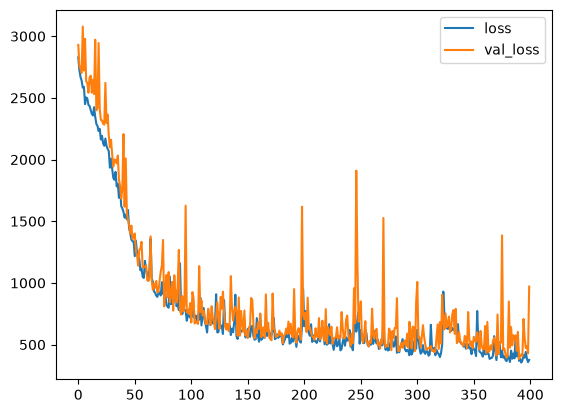

In [ ]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()



In [ ]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))



Test data evaluation:
805.3408813476562

Train data evaluation:
748.6492309570312


In [ ]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df



43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Test True Y,Model Predictions
0,24.3878,25.025932
1,454.8700,441.034210
2,24.9900,17.636139
3,243.9878,241.325150
4,24.3878,26.514233
...,...,...
1359,60.9878,57.400082
1360,48.7878,67.720467
1361,146.3878,130.532333
1362,12.1878,8.842243


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

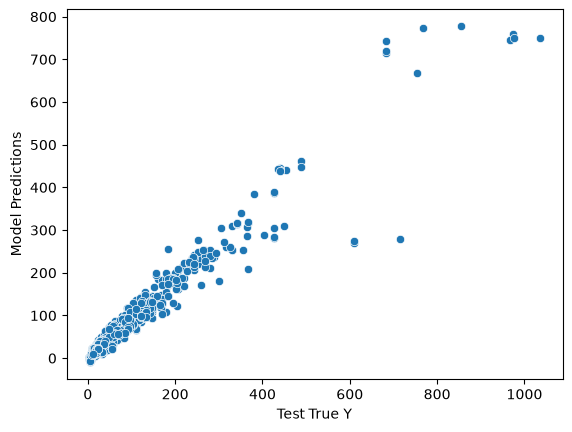

In [ ]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [ ]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
11.99 $

MSE
805.34 $^2

RMSE:
28.38 $

R-squared:
0.92

Explained variance score:
0.93


C:\Users\OMISTAJA\AppData\Local\Temp\ipykernel_17192\2285612724.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - test_predictions))


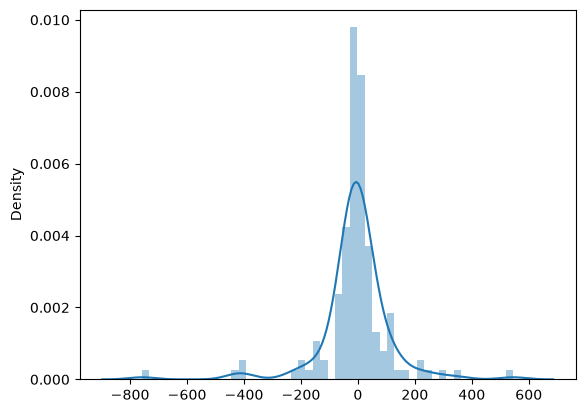

In [ ]:
# if the prediction distribution are far from normal distribution
# then the model is not probably good enough
# distplot is deprecating in future pandas-version
# unfortunately, there's no exact alternative to do this plot at the moment
sns.distplot((y_test - test_predictions))
plt.show()
plt.close()

